# Deep Learning Individual Project — Submission

**Student ID:** s3343711

---

## Academic Honesty Declaration

I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.

## 1. Introduction

This project implements a deep learning solution for **multiclass image classification** on a custom dataset containing 16,000 grayscale images (32×32 pixels) distributed across 4 classes.

### Objectives
1. Perform thorough exploratory data analysis (EDA) to understand the dataset
2. Design and implement appropriate preprocessing pipelines
3. Build and train a CNN model for accurate classification
4. Evaluate model performance and discuss results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Global constants
RANDOM_SEED = 42
SAMPLES_PER_CLASS_VISUALIZATION = 6
PIXEL_SAMPLE_SIZE = 50000

# Color palette for visualization (supports up to 10 classes)
COLOR_PALETTE = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

# VISUALIZATION HELPER FUNCTIONS

def plot_training_history(history, title_prefix="", figsize=(14, 5)):
    """
    Plot training and validation accuracy/loss curves.

    Parameters:
        history: Keras history object from model.fit()
        title_prefix: Optional prefix for plot titles
        figsize: Figure size tuple
    """
    figure, axes = plt.subplots(1, 2, figsize=figsize)
    prefix = f"{title_prefix} " if title_prefix else ""

    # Accuracy plot
    axes[0].plot(history.history["accuracy"], label="Training", linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2)
    axes[0].set_title(f"{prefix}Model Accuracy", fontsize=14)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history["loss"], label="Training", linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2)
    axes[1].set_title(f"{prefix}Model Loss", fontsize=14)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "epochs": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_accuracy": max(history.history["val_accuracy"]),
    }


def plot_confusion_matrices(y_true, y_pred, class_names, figsize=(14, 5)):
    """
    Plot confusion matrices (counts and percentages) side by side.

    Parameters:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class name strings
        figsize: Figure size tuple
    """
    num_classes = len(class_names)
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = (
        conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    )

    figure, axes = plt.subplots(1, 2, figsize=figsize)

    # Helper to plot single confusion matrix
    def plot_single_matrix(axis, matrix, title, fmt_func, threshold_func):
        im = axis.imshow(matrix, cmap="Blues")
        axis.set_title(title, fontsize=14)
        axis.set_xlabel("Predicted Label")
        axis.set_ylabel("True Label")
        axis.set_xticks(range(num_classes))
        axis.set_yticks(range(num_classes))
        axis.set_xticklabels(class_names)
        axis.set_yticklabels(class_names)

        # Add text annotations
        for row in range(num_classes):
            for col in range(num_classes):
                text_color = "white" if threshold_func(matrix[row, col]) else "black"
                axis.text(
                    col,
                    row,
                    fmt_func(matrix[row, col]),
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=12,
                    fontweight="bold",
                )
        return im

    # Raw counts
    im1 = plot_single_matrix(
        axes[0],
        conf_matrix,
        "Confusion Matrix (Counts)",
        lambda x: f"{x}",
        lambda x: x > conf_matrix.max() / 2,
    )
    plt.colorbar(im1, ax=axes[0])

    # Percentages
    im2 = plot_single_matrix(
        axes[1],
        conf_matrix_normalized,
        "Confusion Matrix (Percentages)",
        lambda x: f"{x:.1f}%",
        lambda x: x > 50,
    )
    plt.colorbar(im2, ax=axes[1], format="%.0f%%")

    plt.tight_layout()
    plt.show()

    # Print per-class accuracy
    print("\nPer-Class Accuracy:")
    print("-" * 40)
    for i in range(num_classes):
        accuracy = conf_matrix[i, i] / conf_matrix[i, :].sum() * 100
        print(f"{class_names[i]}: {accuracy:.2f}%")


def plot_sample_predictions(
    images,
    true_labels,
    pred_labels,
    class_names,
    class_colors,
    num_classes,
    samples_per_class,
    figsize=(14, 10),
    seed=42,
):
    """
    Plot sample predictions with correct/incorrect color coding.

    Parameters:
        images: Image array (N, H, W) or (N, H, W, 1)
        true_labels: True class labels
        pred_labels: Predicted class labels
        class_names: List of class name strings
        class_colors: List of class colors
        num_classes: Number of classes
        samples_per_class: Number of samples to show per class
        figsize: Figure size tuple
        seed: Random seed for sample selection
    """
    np.random.seed(seed)
    figure, axes = plt.subplots(num_classes, samples_per_class, figsize=figsize)
    figure.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)", fontsize=14)

    # Select samples for each class
    sample_indices = []
    for class_idx in range(num_classes):
        class_indices = np.where(true_labels == class_idx)[0]
        selected = np.random.choice(
            class_indices, size=samples_per_class, replace=False
        )
        sample_indices.extend(selected)

    for idx, sample_idx in enumerate(sample_indices):
        row = idx // samples_per_class
        col = idx % samples_per_class

        # Handle both (H, W) and (H, W, 1) image shapes
        image = images[sample_idx]
        if image.ndim == 3:
            image = image[:, :, 0]

        true_label = true_labels[sample_idx]
        pred_label = pred_labels[sample_idx]

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        is_correct = true_label == pred_label
        title_color = "green" if is_correct else "red"
        axes[row, col].set_title(
            f"T:{true_label} P:{pred_label}", color=title_color, fontsize=10
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    correct = np.sum(pred_labels == true_labels)
    total = len(true_labels)
    print(f"\nPrediction Summary:")
    print(f"  Correct: {correct:,} ({correct/total*100:.2f}%)")
    print(f"  Incorrect: {total-correct:,} ({(total-correct)/total*100:.2f}%)")


def plot_training_comparison(
    history1, history2, label1="Baseline", label2="Augmented", figsize=(14, 10)
):
    """
    Plot side-by-side comparison of two training histories.

    Parameters:
        history1: First Keras history object
        history2: Second Keras history object
        label1: Label for first model
        label2: Label for second model
        figsize: Figure size tuple
    """
    figure, axes = plt.subplots(2, 2, figsize=figsize)
    figure.suptitle(f"Training Comparison: {label1} vs {label2}", fontsize=14)

    # Define plot configurations: (row, col, history, metric, title, color)
    plot_configs = [
        (0, 0, history1, "accuracy", f"{label1} Accuracy", "tab:blue"),
        (0, 1, history2, "accuracy", f"{label2} Accuracy", "tab:green"),
        (1, 0, history1, "loss", f"{label1} Loss", "tab:blue"),
        (1, 1, history2, "loss", f"{label2} Loss", "tab:green"),
    ]

    for row, col, hist, metric, title, color in plot_configs:
        ax = axes[row, col]
        ax.plot(
            hist.history[metric],
            label="Training",
            linestyle="-",
            linewidth=2,
            color=color,
        )
        ax.plot(
            hist.history[f"val_{metric}"],
            label="Validation",
            linestyle="--",
            linewidth=2,
            color=color,
            alpha=0.7,
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [2]:
# Load Dataset
dataset = np.load("4class_32x32.npz")
X = dataset["X"]
y = dataset["y"]

# Discover dataset properties dynamically
UNIQUE_CLASSES = np.unique(y)
NUM_CLASSES = len(UNIQUE_CLASSES)
TOTAL_SAMPLES = len(y)

# Generate class names and colors dynamically based on discovered classes
CLASS_NAMES = [f"Class {class_id}" for class_id in UNIQUE_CLASSES]
CLASS_COLORS = COLOR_PALETTE[:NUM_CLASSES]

# Display dataset structure
print("DATASET OVERVIEW")
print(f"Images array (X):")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtype}")
print(f"  Memory size: {X.nbytes / (1024**2):.2f} MB")
print(f"Labels array (y):")
print(f"  Shape: {y.shape}")
print(f"  Data type: {y.dtype}")
print(f"  Unique classes: {UNIQUE_CLASSES}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Total samples: {TOTAL_SAMPLES:,}")

DATASET OVERVIEW
Images array (X):
  Shape: (16000, 32, 32)
  Data type: float32
  Memory size: 62.50 MB
Labels array (y):
  Shape: (16000,)
  Data type: int64
  Unique classes: [0 1 2 3]
  Number of classes: 4
  Total samples: 16,000


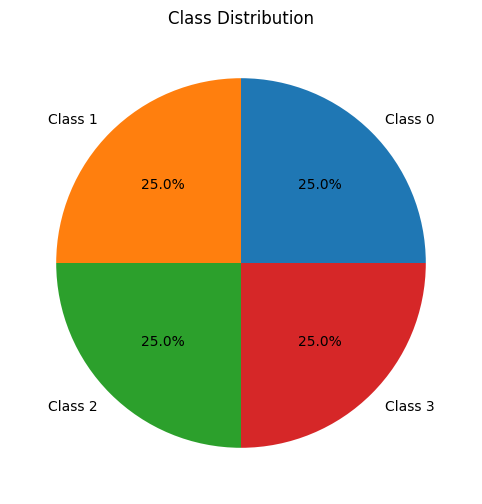


Class Distribution Summary:
----------------------------------------
Class 0: 4,000 samples (25.0%)
Class 1: 4,000 samples (25.0%)
Class 2: 4,000 samples (25.0%)
Class 3: 4,000 samples (25.0%)

Total: 16,000 samples

Observation: Dataset has perfectly balanced classes (4000 samples each).


In [3]:
# Class Distribution Analysis
_, class_counts = np.unique(y, return_counts=True)

# Pie chart showing class proportions (using consistent class colors)
figure, axis = plt.subplots(figsize=(8, 6))
axis.pie(class_counts, labels=CLASS_NAMES, autopct="%1.1f%%", colors=CLASS_COLORS)
axis.set_title("Class Distribution")
plt.show()

# Print summary
print("\nClass Distribution Summary:")
print("-" * 40)
for class_index, count in enumerate(class_counts):
    percentage = (count / TOTAL_SAMPLES) * 100
    print(f"{CLASS_NAMES[class_index]}: {count:,} samples ({percentage:.1f}%)")
print(f"\nTotal: {TOTAL_SAMPLES:,} samples")
print("\nObservation: Dataset has perfectly balanced classes (4000 samples each).")

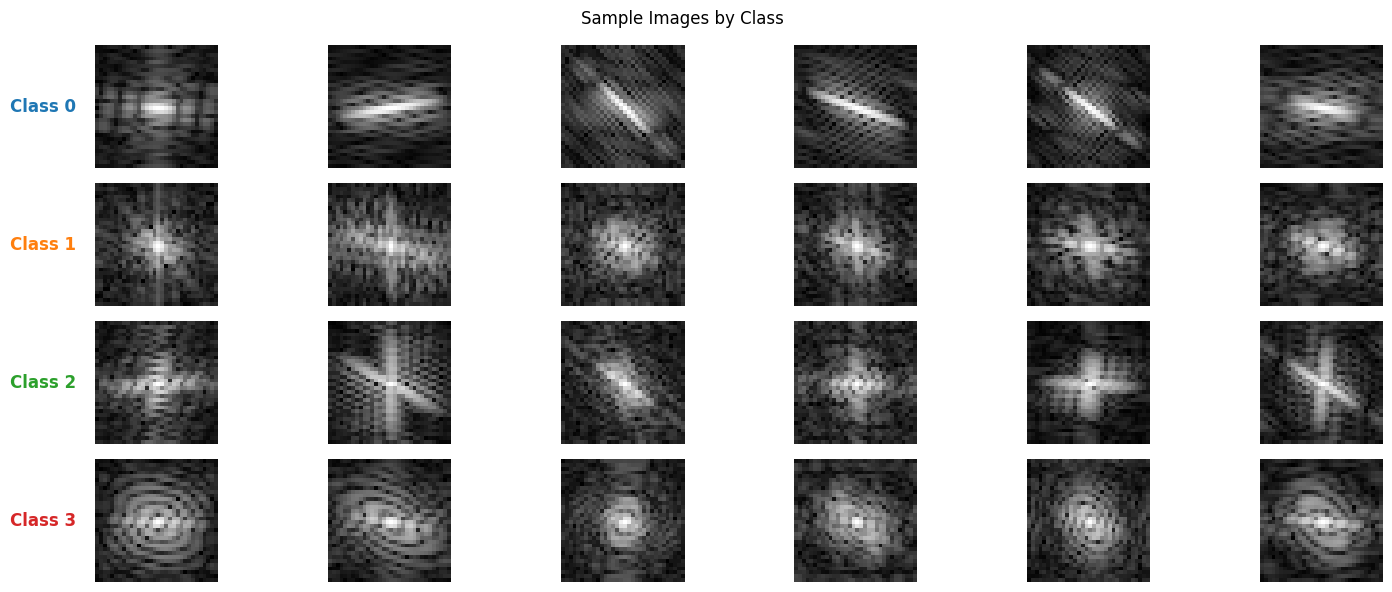


Visual Observations:
Images are 32x32 pixels in grayscale
Each class appears to have certain visual patterns


In [4]:
# Sample Images Visualization - Organized by Class
figure, axes = plt.subplots(
    NUM_CLASSES, SAMPLES_PER_CLASS_VISUALIZATION, figsize=(16, 6)
)
figure.suptitle("Sample Images by Class")

for class_index in range(NUM_CLASSES):
    class_indices = np.where(y == class_index)[0]
    selected_indices = np.random.choice(
        class_indices, size=SAMPLES_PER_CLASS_VISUALIZATION, replace=False
    )

    for sample_position, image_index in enumerate(selected_indices):
        axis = axes[class_index, sample_position]
        axis.imshow(X[image_index], cmap="gray")
        axis.axis("off")

    # Add class label on the left side of each row (with class color)
    axes[class_index, 0].text(
        -0.15,
        0.5,
        CLASS_NAMES[class_index],
        transform=axes[class_index, 0].transAxes,
        fontsize=12,
        fontweight="bold",
        color=CLASS_COLORS[class_index],
        va="center",
        ha="right",
    )

plt.tight_layout()
plt.subplots_adjust(left=0.08)  # Make room for row labels
plt.show()

print("\nVisual Observations:")
print("Images are 32x32 pixels in grayscale")
print("Each class appears to have certain visual patterns")

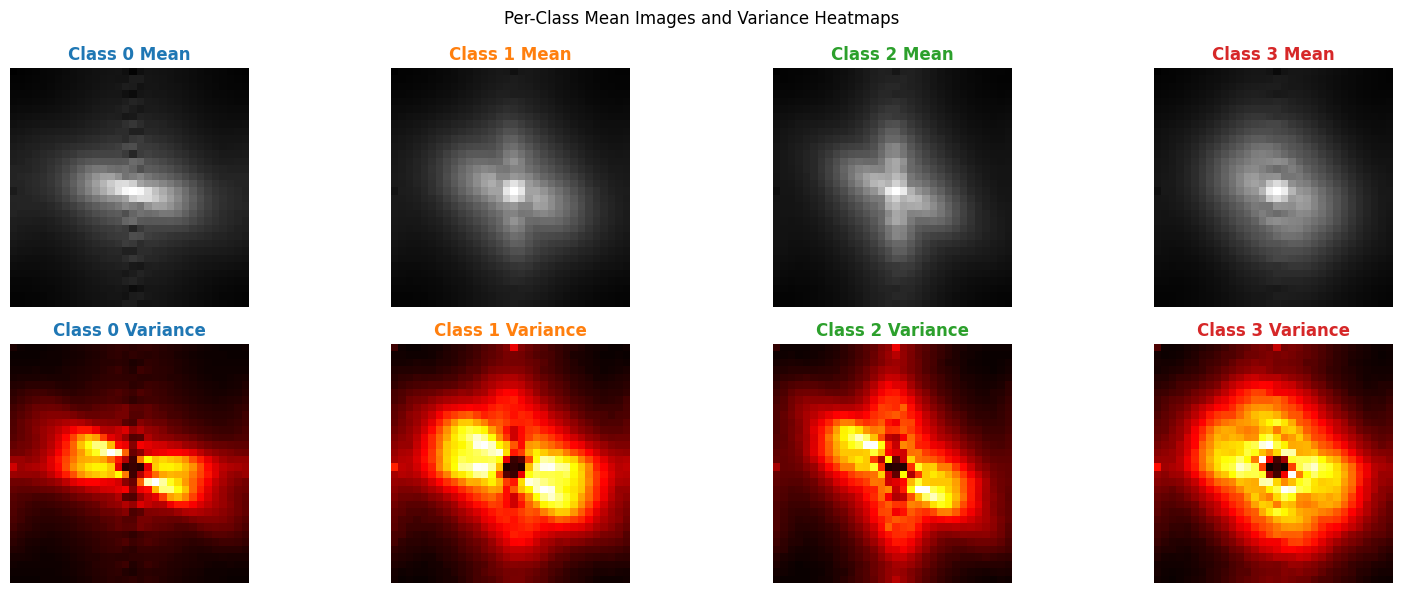


Per-Class Pixel Statistics:
Class    Mean         Std Dev      Max Variance Location
-------------------------------------------------------
0        0.8715       0.6385       (14, 13)
1        1.0933       0.7085       (13, 12)
2        1.0591       0.7129       (13, 13)
3        1.1292       0.7133       (13, 15)


In [5]:
# Per-Class Analysis: Mean Images and Variance Heatmaps
figure, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 6))
figure.suptitle("Per-Class Mean Images and Variance Heatmaps")

class_pixel_statistics = {}

for class_index in range(NUM_CLASSES):
    class_mask = y == class_index
    class_images = X[class_mask]

    mean_image = np.mean(class_images, axis=0)
    variance_image = np.var(class_images, axis=0)

    class_pixel_statistics[class_index] = {
        "mean": np.mean(class_images),
        "std": np.std(class_images),
        "max_variance_location": np.unravel_index(
            np.argmax(variance_image), variance_image.shape
        ),
    }

    # Mean image (with class-colored title)
    axes[0, class_index].imshow(mean_image, cmap="gray")
    axes[0, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Mean",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[0, class_index].axis("off")

    # Variance heatmap (with class-colored title)
    axes[1, class_index].imshow(variance_image, cmap="hot")
    axes[1, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Variance",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[1, class_index].axis("off")

plt.tight_layout()
plt.show()

# Print per-class statistics
print("\nPer-Class Pixel Statistics:")
print(f"{'Class':<8} {'Mean':<12} {'Std Dev':<12} {'Max Variance Location':<20}")
print("-" * 55)
for class_index, statistics in class_pixel_statistics.items():
    location = statistics["max_variance_location"]
    print(
        f"{class_index:<8} {statistics['mean']:<12.4f} {statistics['std']:<12.4f} ({location[0]}, {location[1]})"
    )

### EDA Complete

The exploratory data analysis has revealed the key characteristics of our dataset. Next, we proceed to data preprocessing based on these findings.

## 3. Train/Validation Split & Preprocessing

### Preprocessing Strategy

Based on the EDA findings, we implement the following preprocessing pipeline:

1. **Normalization**: The pixel values range from 0 to ~5.07 with varying distributions. We'll normalize to [0, 1] range using min-max scaling for stable training.

2. **Channel Dimension**: Add a channel dimension for CNN compatibility (32×32 → 32×32×1).

3. **Train/Validation Split**: Use 80-20 stratified split to ensure balanced class representation in both sets.

### Justification
- **Stratified split** ensures each class maintains its 25% proportion in both training and validation sets
- **80-20 ratio** provides sufficient training data (12,800 samples) while keeping enough validation data (3,200 samples) for reliable performance estimation
- **Normalization** helps with gradient stability and faster convergence during training


In [6]:
# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Preprocessing function
def preprocess_data(X_raw):
  
    X_min = X_raw.min()
    X_max = X_raw.max()
    X_normalized = (X_raw - X_min) / (X_max - X_min)
    
    # Add channel dimension for CNN
    X_processed = X_normalized[..., np.newaxis]
    
    return X_processed.astype(np.float32)

# Store original min/max for later use in predict_fn
PIXEL_MIN = X.min()
PIXEL_MAX = X.max()

print(f"Original pixel range: [{PIXEL_MIN:.4f}, {PIXEL_MAX:.4f}]")

# Preprocess the entire dataset
X_processed = preprocess_data(X)
print(f"Processed pixel range: [{X_processed.min():.4f}, {X_processed.max():.4f}]")
print(f"Processed shape: {X_processed.shape}")


Original pixel range: [0.0000, 5.0696]
Processed pixel range: [0.0000, 1.0000]
Processed shape: (16000, 32, 32, 1)


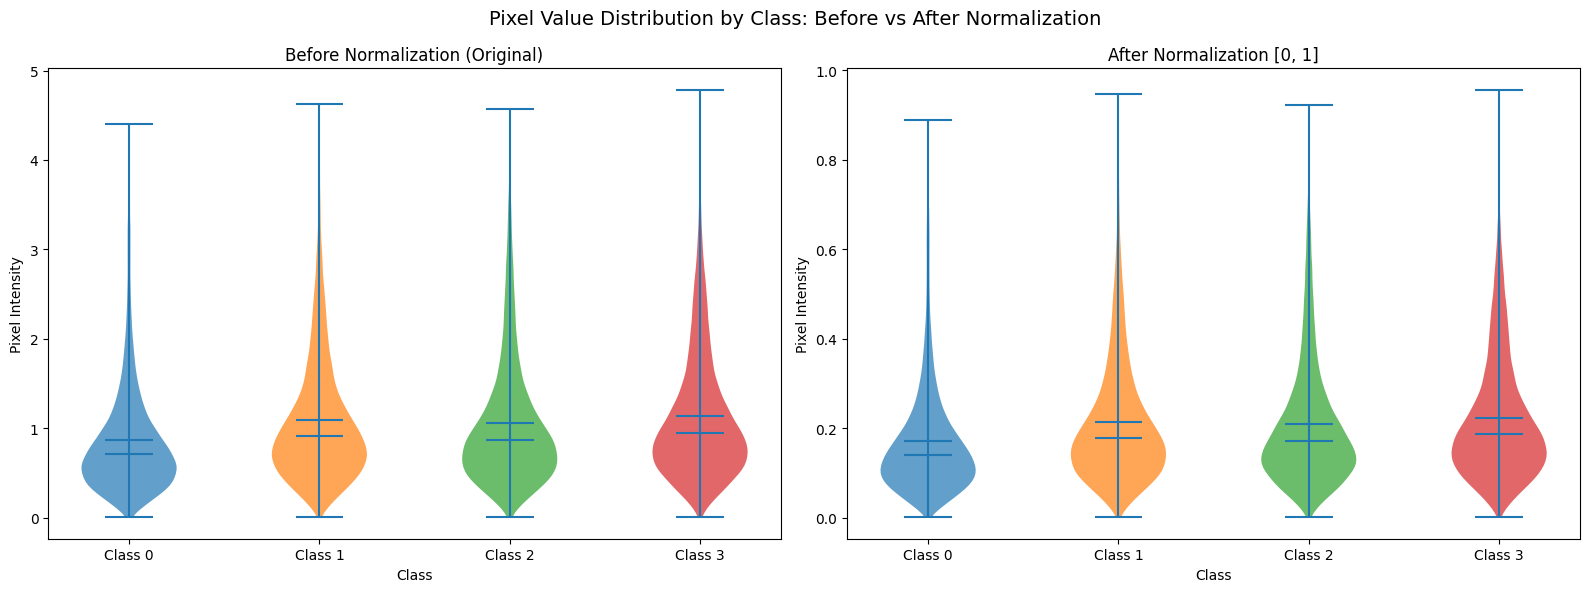


Pixel Value Statistics Comparison (Original vs Normalized):
-------------------------------------------------------------------------------------------------------------------
Class      ori_mean   norm_mean   ori_std    norm_std   ori_min    norm_min   ori_max    norm_max  
-------------------------------------------------------------------------------------------------------------------
Class 0    0.8715     0.1719      0.6385     0.1259     0.0001     0.0000     4.6706     0.9213    
Class 1    1.0933     0.2157      0.7085     0.1398     0.0000     0.0000     5.0577     0.9977    
Class 2    1.0591     0.2089      0.7129     0.1406     0.0001     0.0000     5.0373     0.9936    
Class 3    1.1292     0.2227      0.7133     0.1407     0.0003     0.0001     5.0696     1.0000    


In [7]:
# Helper functions for pixel distribution visualization
def sample_pixels_by_class(data, labels, sample_size):
    sampled_pixels = []
    for class_index in range(NUM_CLASSES):
        class_pixels = data[labels == class_index].flatten()
        if len(class_pixels) > sample_size:
            sampled = np.random.choice(class_pixels, size=sample_size, replace=False)
        else:
            sampled = class_pixels
        sampled_pixels.append(sampled)
    return sampled_pixels


def configure_violin_plot(axis, violin_parts, title):
    for class_index, body in enumerate(violin_parts["bodies"]):
        body.set_facecolor(CLASS_COLORS[class_index])
        body.set_alpha(0.7)
    axis.set_ylabel("Pixel Intensity")
    axis.set_xlabel("Class")
    axis.set_title(title)
    axis.set_xticks(range(1, NUM_CLASSES + 1))
    axis.set_xticklabels(CLASS_NAMES)


# Compare pixel value distributions: Before vs After Normalization
figure, axes = plt.subplots(1, 2, figsize=(16, 6))
figure.suptitle(
    "Pixel Value Distribution by Class: Before vs After Normalization", fontsize=14
)

# Prepare sampled data for both plots
pixels_before_norm = sample_pixels_by_class(X, y, PIXEL_SAMPLE_SIZE)
pixels_after_norm = sample_pixels_by_class(X_processed, y, PIXEL_SAMPLE_SIZE)

# Create and configure violin plots
plot_configs = [
    (axes[0], pixels_before_norm, "Before Normalization (Original)"),
    (axes[1], pixels_after_norm, "After Normalization [0, 1]"),
]

for axis, pixel_data, title in plot_configs:
    violin_parts = axis.violinplot(pixel_data, showmeans=True, showmedians=True)
    configure_violin_plot(axis, violin_parts, title)

plt.tight_layout()
plt.show()

# Print comparison statistics
print("\nPixel Value Statistics Comparison (Original vs Normalized):")
print("-" * 115)
print(
    f"{'Class':<10} {'ori_mean':<10} {'norm_mean':<11} {'ori_std':<10} {'norm_std':<10} "
    f"{'ori_min':<10} {'norm_min':<10} {'ori_max':<10} {'norm_max':<10}"
)
print("-" * 115)
for class_index in range(NUM_CLASSES):
    class_mask = y == class_index
    ori_data = X[class_mask]
    norm_data = X_processed[class_mask]
    print(
        f"{CLASS_NAMES[class_index]:<10} "
        f"{ori_data.mean():<10.4f} {norm_data.mean():<11.4f} "
        f"{ori_data.std():<10.4f} {norm_data.std():<10.4f} "
        f"{ori_data.min():<10.4f} {norm_data.min():<10.4f} "
        f"{ori_data.max():<10.4f} {norm_data.max():<10.4f}"
    )

In [8]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y
)

print("Train/Validation Split Summary:")
print("-" * 40)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(y)*100:.1f}%)")

# Verify stratification
print("\nClass Distribution in Splits:")
print(f"{'Class':<8} {'Train':<12} {'Validation':<12}")
print("-" * 35)
for class_index in range(NUM_CLASSES):
    train_count = np.sum(y_train == class_index)
    val_count = np.sum(y_val == class_index)
    print(f"{class_index:<8} {train_count:<12} {val_count:<12}")
    
print("\n✓ Stratification confirmed: Each class has proportional representation")


Train/Validation Split Summary:
----------------------------------------
Training set:   12,800 samples (80.0%)
Validation set: 3,200 samples (20.0%)

Class Distribution in Splits:
Class    Train        Validation  
-----------------------------------
0        3200         800         
1        3200         800         
2        3200         800         
3        3200         800         

✓ Stratification confirmed: Each class has proportional representation


## 4. Architecture Reasoning

### Why Convolutional Neural Network (CNN)?

CNNs are the ideal choice for this image classification task because:

1. **Spatial Hierarchy Learning**: CNNs can learn hierarchical features - from simple edges in early layers to complex patterns in deeper layers
2. **Translation Invariance**: Convolutional layers with pooling provide robustness to small shifts in the image
3. **Parameter Efficiency**: Weight sharing in convolutional kernels significantly reduces parameters compared to fully-connected networks
4. **Proven Performance**: CNNs are the state-of-the-art for image classification tasks

### Architecture Design

Given the input size (32×32×1), we design a compact yet effective CNN:

| Layer | Output Shape | Parameters | Rationale |
|-------|-------------|------------|-----------|
| Input | 32×32×1 | - | Grayscale image |
| Conv2D (32 filters, 3×3) | 30×30×32 | 320 | Extract low-level features (edges, textures) |
| BatchNorm + ReLU | 30×30×32 | 64 | Stabilize training, add non-linearity |
| MaxPool2D (2×2) | 15×15×32 | - | Reduce spatial dimensions, add translation invariance |
| Conv2D (64 filters, 3×3) | 13×13×64 | 18,496 | Extract mid-level features (shapes, parts) |
| BatchNorm + ReLU | 13×13×64 | 128 | Stabilize training |
| MaxPool2D (2×2) | 6×6×64 | - | Further spatial reduction |
| Conv2D (128 filters, 3×3) | 4×4×128 | 73,856 | Extract high-level features (patterns) |
| BatchNorm + ReLU | 4×4×128 | 256 | Stabilize training |
| GlobalAvgPool2D | 128 | - | Reduce to feature vector, less overfitting than Flatten |
| Dropout (0.5) | 128 | - | Regularization |
| Dense (64) | 64 | 8,256 | Learn class-specific combinations |
| Dense (4, softmax) | 4 | 260 | 4-class output probabilities |

### Design Decisions

- **Filter progression (32→64→128)**: Gradually increasing filters captures increasingly complex features
- **3×3 kernels**: Small kernels are computationally efficient and when stacked, can capture large receptive fields
- **BatchNormalization**: Accelerates training and provides mild regularization
- **GlobalAveragePooling**: Reduces overfitting compared to Flatten+Dense; creates more interpretable feature maps
- **Dropout (50%)**: Strong regularization to prevent overfitting on 12,800 training samples


## 4. Model Implementation

### Building the CNN Architecture


In [9]:
def build_cnn_model(input_shape, num_classes, augmentation_layer=None):
    """
    Build a CNN model for image classification with optional data augmentation.
    
    Parameters:
        input_shape: tuple, shape of input images (height, width, channels)
        num_classes: int, number of output classes
        augmentation_layer: optional keras Sequential layer for data augmentation
                           (applied only during training)
        
    Returns:
        model: compiled Keras model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Apply data augmentation if provided (only during training)
    if augmentation_layer is not None:
        x = augmentation_layer(inputs)
    else:
        x = inputs
    
    # First Convolutional Block
    x = layers.Conv2D(32, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Second Convolutional Block
    x = layers.Conv2D(64, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Third Convolutional Block
    x = layers.Conv2D(128, (3, 3), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Global Average Pooling (reduces overfitting vs Flatten)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Fully Connected Layers
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# Define input shape based on processed data
INPUT_SHAPE = X_processed.shape[1:]  # (32, 32, 1)

# Build the baseline model (no augmentation)
model = build_cnn_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,084 (398.77 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Architecture Reasoning

### Why Convolutional Neural Network (CNN)?

CNNs are the ideal choice for this image classification task because:

1. **Spatial Hierarchy Learning**: CNNs can learn hierarchical features - from simple edges in early layers to complex patterns in deeper layers
2. **Translation Invariance**: Convolutional layers with pooling provide robustness to small shifts in the image
3. **Parameter Efficiency**: Weight sharing in convolutional kernels significantly reduces parameters compared to fully-connected networks
4. **Proven Performance**: CNNs are the state-of-the-art for image classification tasks

### Architecture Design

Given the input size (32×32×1), we design a compact yet effective CNN:

| Layer | Output Shape | Parameters | Rationale |
|-------|-------------|------------|-----------|
| Input | 32×32×1 | - | Grayscale image |
| Conv2D (32 filters, 3×3) | 30×30×32 | 320 | Extract low-level features (edges, textures) |
| BatchNorm + ReLU | 30×30×32 | 64 | Stabilize training, add non-linearity |
| MaxPool2D (2×2) | 15×15×32 | - | Reduce spatial dimensions, add translation invariance |
| Conv2D (64 filters, 3×3) | 13×13×64 | 18,496 | Extract mid-level features (shapes, parts) |
| BatchNorm + ReLU | 13×13×64 | 128 | Stabilize training |
| MaxPool2D (2×2) | 6×6×64 | - | Further spatial reduction |
| Conv2D (128 filters, 3×3) | 4×4×128 | 73,856 | Extract high-level features (patterns) |
| BatchNorm + ReLU | 4×4×128 | 256 | Stabilize training |
| GlobalAvgPool2D | 128 | - | Reduce to feature vector, less overfitting than Flatten |
| Dropout (0.5) | 128 | - | Regularization |
| Dense (64) | 64 | 8,256 | Learn class-specific combinations |
| Dense (4, softmax) | 4 | 260 | 4-class output probabilities |

### Design Decisions

- **Filter progression (32→64→128)**: Gradually increasing filters captures increasingly complex features
- **3×3 kernels**: Small kernels are computationally efficient and when stacked, can capture large receptive fields
- **BatchNormalization**: Accelerates training and provides mild regularization
- **GlobalAveragePooling**: Reduces overfitting compared to Flatten+Dense; creates more interpretable feature maps
- **Dropout (50%)**: Strong regularization to prevent overfitting on 12,800 training samples


---

## Option B: Train Model from Scratch

This section contains the complete training pipeline. Run this to train the model from scratch and save it.


In [10]:
# Training configuration
EPOCHS = 50  # Reduced from 100; early stopping typically triggers around epoch 30-40
BATCH_SIZE = 32

# Define callbacks
training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

# Train the model
print("Starting training...")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print("-" * 50)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=training_callbacks,
    verbose=1,
)

print("\n" + "=" * 50)
print("Training completed!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")

Starting training...
Training samples: 12800
Validation samples: 3200
Batch size: 32
Max epochs: 50
--------------------------------------------------
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8855 - loss: 0.3196 - val_accuracy: 0.3375 - val_loss: 2.4306 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9449 - loss: 0.1650 - val_accuracy: 0.8125 - val_loss: 0.5359 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9616 - loss: 0.1178 - val_accuracy: 0.7494 - val_loss: 1.0023 - learning_rate: 0.0010
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9688 - loss: 0.0951 - val_accuracy: 0.6966 - val_loss: 3.6083 - learning_rate: 0.0010
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9723 - loss: 0.0842 - val_accuracy: 0.6122 - val_loss: 2.5619 - learning_rate: 0.0010
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9776 - loss: 0.06

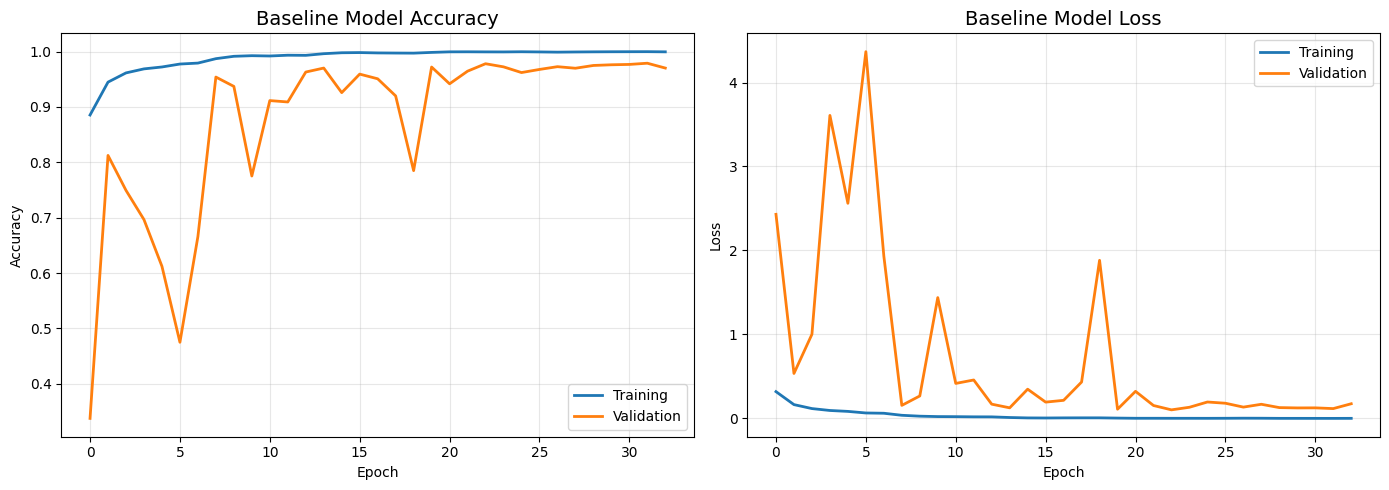


Training Observations:
  - Total epochs trained: 33
  - Best validation loss: 0.1026
  - Best validation accuracy: 0.9791


In [11]:
# Plot training history using helper function
training_stats = plot_training_history(history, title_prefix="Baseline")

print("\nTraining Observations:")
print(f"  - Total epochs trained: {training_stats['epochs']}")
print(f"  - Best validation loss: {training_stats['best_val_loss']:.4f}")
print(f"  - Best validation accuracy: {training_stats['best_val_accuracy']:.4f}")


In [12]:
# Save the trained model
MODEL_PATH = "model_s3343711.h5"
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Verify the saved model

model_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Model file size: {model_size_mb:.2f} MB")


Model saved to: model_s3343711.h5
Model file size: 1.24 MB


---

## Option A: Load Trained Model

This section loads a pre-trained model from the saved `.h5` file. Use this option for quick evaluation without retraining.


In [13]:
# Load the pre-trained model
MODEL_PATH = "model_s3343711.h5"
model = keras.models.load_model(MODEL_PATH)

print(f"Model loaded from: {MODEL_PATH}")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

# Quick summary
model.summary()


Model loaded from: model_s3343711.h5
Model input shape: (None, 32, 32, 1)
Model output shape: (None, 4)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,086 (398.78 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

---

## Prediction Function (Required)

The `predict_fn` function is the standardized interface for model predictions. It works after either Option A or Option B.


In [14]:
def predict_fn(X32x32: np.ndarray) -> np.ndarray:
    # Ensure input is the correct shape
    if X32x32.ndim == 2:
        # Single image: (32, 32) -> (1, 32, 32)
        X32x32 = X32x32[np.newaxis, ...]
    
    # Preprocess: normalize to [0, 1] and add channel dimension
    X_min = X32x32.min()
    X_max = X32x32.max()
    
    # Handle edge case where all values are the same
    if X_max - X_min > 0:
        X_normalized = (X32x32 - X_min) / (X_max - X_min)
    else:
        X_normalized = X32x32 - X_min
    
    # Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
    X_processed = X_normalized[..., np.newaxis].astype(np.float32)
    
    # Get model predictions (probabilities)
    predictions_proba = model.predict(X_processed, verbose=0)
    
    # Convert probabilities to class labels
    predictions = np.argmax(predictions_proba, axis=1).astype(np.int64)
    
    return predictions

# Test the predict_fn with a small sample
print("Testing predict_fn...")
test_samples = X[:5]  # Use original unnormalized data
test_predictions = predict_fn(test_samples)
print(f"Input shape: {test_samples.shape}")
print(f"Output shape: {test_predictions.shape}")
print(f"Output dtype: {test_predictions.dtype}")
print(f"Predicted labels: {test_predictions}")
print(f"True labels:      {y[:5]}")
print("\n✓ predict_fn is working correctly")


Testing predict_fn...
Input shape: (5, 32, 32)
Output shape: (5,)
Output dtype: int64
Predicted labels: [1 0 1 0 0]
True labels:      [1 0 1 0 0]

✓ predict_fn is working correctly


---

## Dev-Set Evaluation and Discussion

Comprehensive evaluation of the trained model on the validation set.


In [15]:
# Evaluate on validation set using model.evaluate
print("Model Evaluation on Validation Set:")
print("=" * 50)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Get predictions using predict_fn (to verify it works correctly)
# Note: We need to use the original unprocessed validation data
# But since we already have X_val processed, let's use model.predict directly
y_val_pred_proba = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Classification report
print("\n" + "=" * 50)
print("Classification Report:")
print("=" * 50)
print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES))


Model Evaluation on Validation Set:
Validation Loss: 0.1026
Validation Accuracy: 0.9781 (97.81%)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.98      0.98       800
     Class 1       0.98      0.98      0.98       800
     Class 2       0.97      0.97      0.97       800
     Class 3       0.98      0.98      0.98       800

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



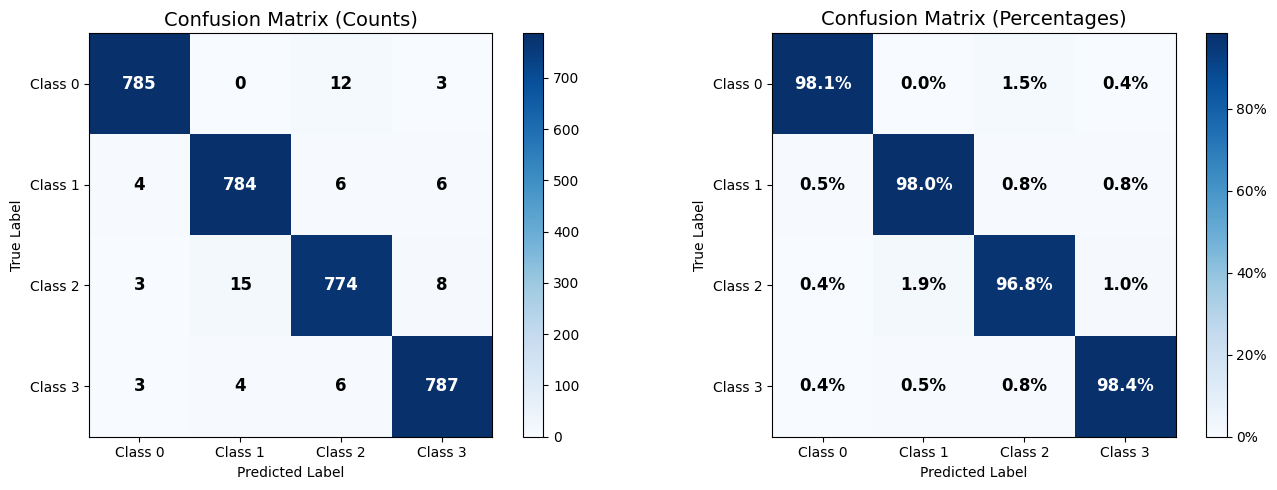


Per-Class Accuracy:
----------------------------------------
Class 0: 98.12%
Class 1: 98.00%
Class 2: 96.75%
Class 3: 98.38%


In [ ]:
# Confusion Matrix Visualization using helper function
plot_confusion_matrices(y_val, y_val_pred, CLASS_NAMES)

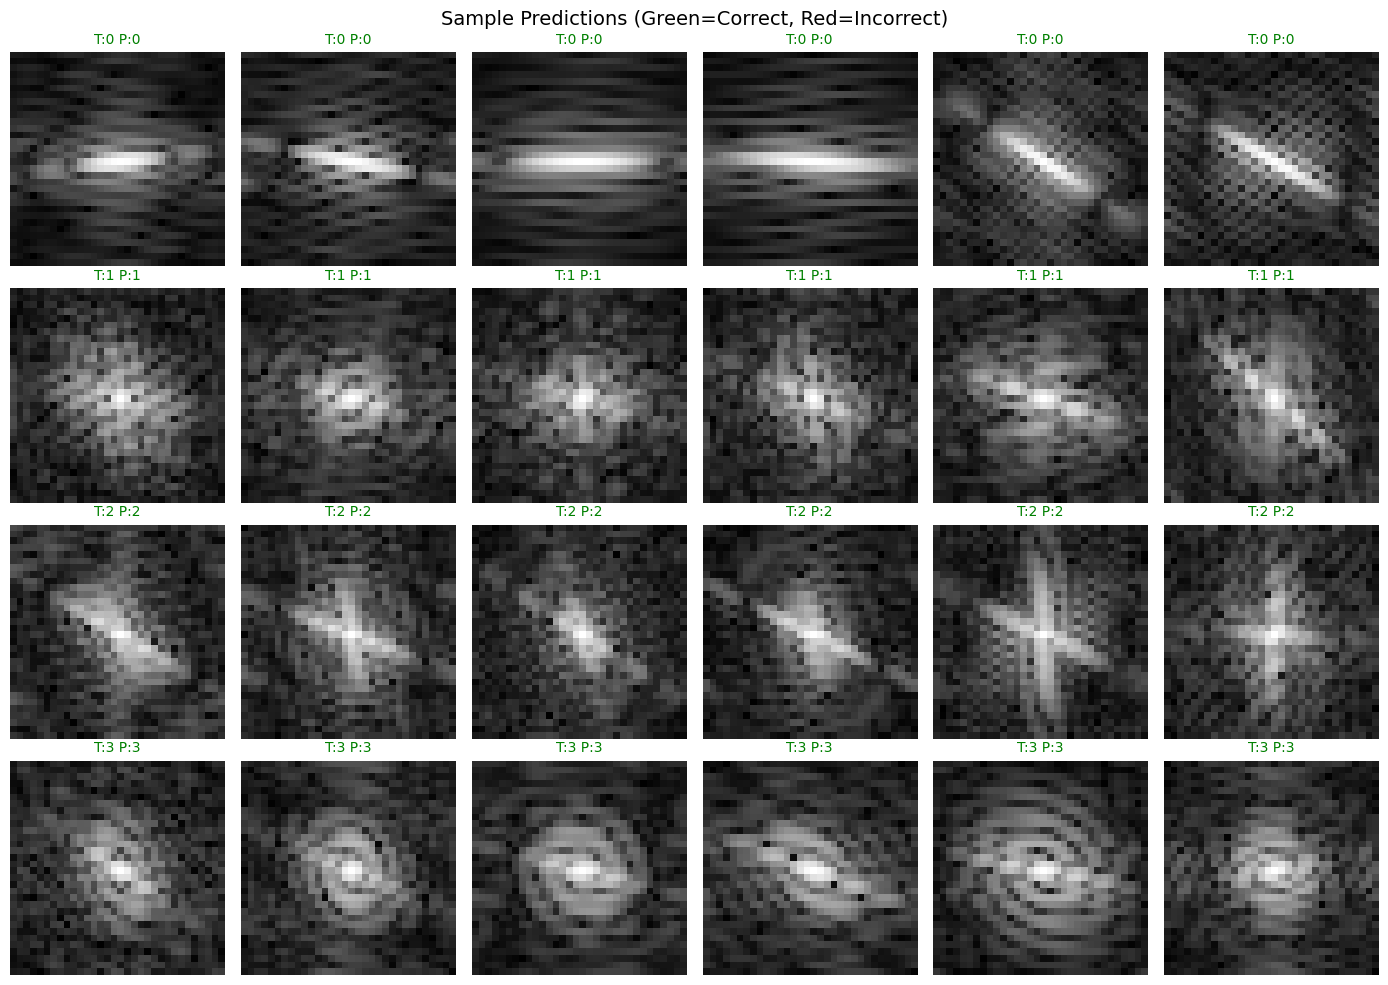


Prediction Summary:
  Correct: 3,130 (97.81%)
  Incorrect: 70 (2.19%)


In [17]:
# Visualize sample predictions using helper function
plot_sample_predictions(
    images=X_val,
    true_labels=y_val,
    pred_labels=y_val_pred,
    class_names=CLASS_NAMES,
    class_colors=CLASS_COLORS,
    num_classes=NUM_CLASSES,
    samples_per_class=SAMPLES_PER_CLASS_VISUALIZATION,
    seed=RANDOM_SEED
)


---

## Ablation Study: Data Augmentation

This section explores the impact of **data augmentation** on model performance. Data augmentation artificially increases training data diversity by applying random transformations, which can help reduce overfitting and improve generalization.

### Augmentation Techniques Applied
- **RandomRotation**: ±10% rotation to handle slight orientation variations
- **RandomZoom**: ±10% zoom to handle scale variations
- **RandomTranslation**: ±10% horizontal/vertical shift for positional robustness

### Hypothesis
Adding data augmentation should:
1. Reduce the gap between training and validation accuracy
2. Potentially improve validation accuracy through better generalization
3. Make the model more robust to input variations


In [18]:
# Store baseline model accuracy for comparison
baseline_val_accuracy = max(history.history['val_accuracy'])
baseline_train_accuracy = history.history['accuracy'][-1]
print(f"Baseline Model Performance:")
print(f"  Training Accuracy:   {baseline_train_accuracy:.4f}")
print(f"  Validation Accuracy: {baseline_val_accuracy:.4f}")

# Define data augmentation layer
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),         # ±10% rotation
    layers.RandomZoom(0.1),             # ±10% zoom
    layers.RandomTranslation(0.1, 0.1)  # ±10% horizontal/vertical shift
], name='data_augmentation')

# Build model WITH data augmentation using the same build_cnn_model function
model_augmented = build_cnn_model(
    input_shape=INPUT_SHAPE, 
    num_classes=NUM_CLASSES, 
    augmentation_layer=data_augmentation  # Pass augmentation layer
)

print("\nModel with Data Augmentation:")
model_augmented.summary()


Baseline Model Performance:
  Training Accuracy:   0.9996
  Validation Accuracy: 0.9791

Model with Data Augmentation:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,084 (398.77 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Train the augmented model with same configuration
print("Training model WITH data augmentation...")
print("-" * 50)

# Reset random seeds for fair comparison
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Use same callbacks
augmented_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history_augmented = model_augmented.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=augmented_callbacks,
    verbose=1
)

print("\n" + "=" * 50)
print("Training with augmentation completed!")
print(f"Best validation accuracy: {max(history_augmented.history['val_accuracy']):.4f}")
print(f"Final training accuracy: {history_augmented.history['accuracy'][-1]:.4f}")


Training model WITH data augmentation...
--------------------------------------------------
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7594 - loss: 0.6030 - val_accuracy: 0.4712 - val_loss: 1.8020 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8455 - loss: 0.4223 - val_accuracy: 0.3678 - val_loss: 3.0864 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8712 - loss: 0.3549 - val_accuracy: 0.4844 - val_loss: 5.2261 - learning_rate: 0.0010
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8888 - loss: 0.3132 - val_accuracy: 0.5775 - val_loss: 1.6296 - learning_rate: 0.0010
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8924 - loss: 0.2986 - val_accuracy: 0.6256 - val_loss: 1.3369 - learning_rate: 0.0010
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9007 - loss: 0.2766 - val_accuracy: 0.6444 - val_loss: 2.6105 - learning_ra

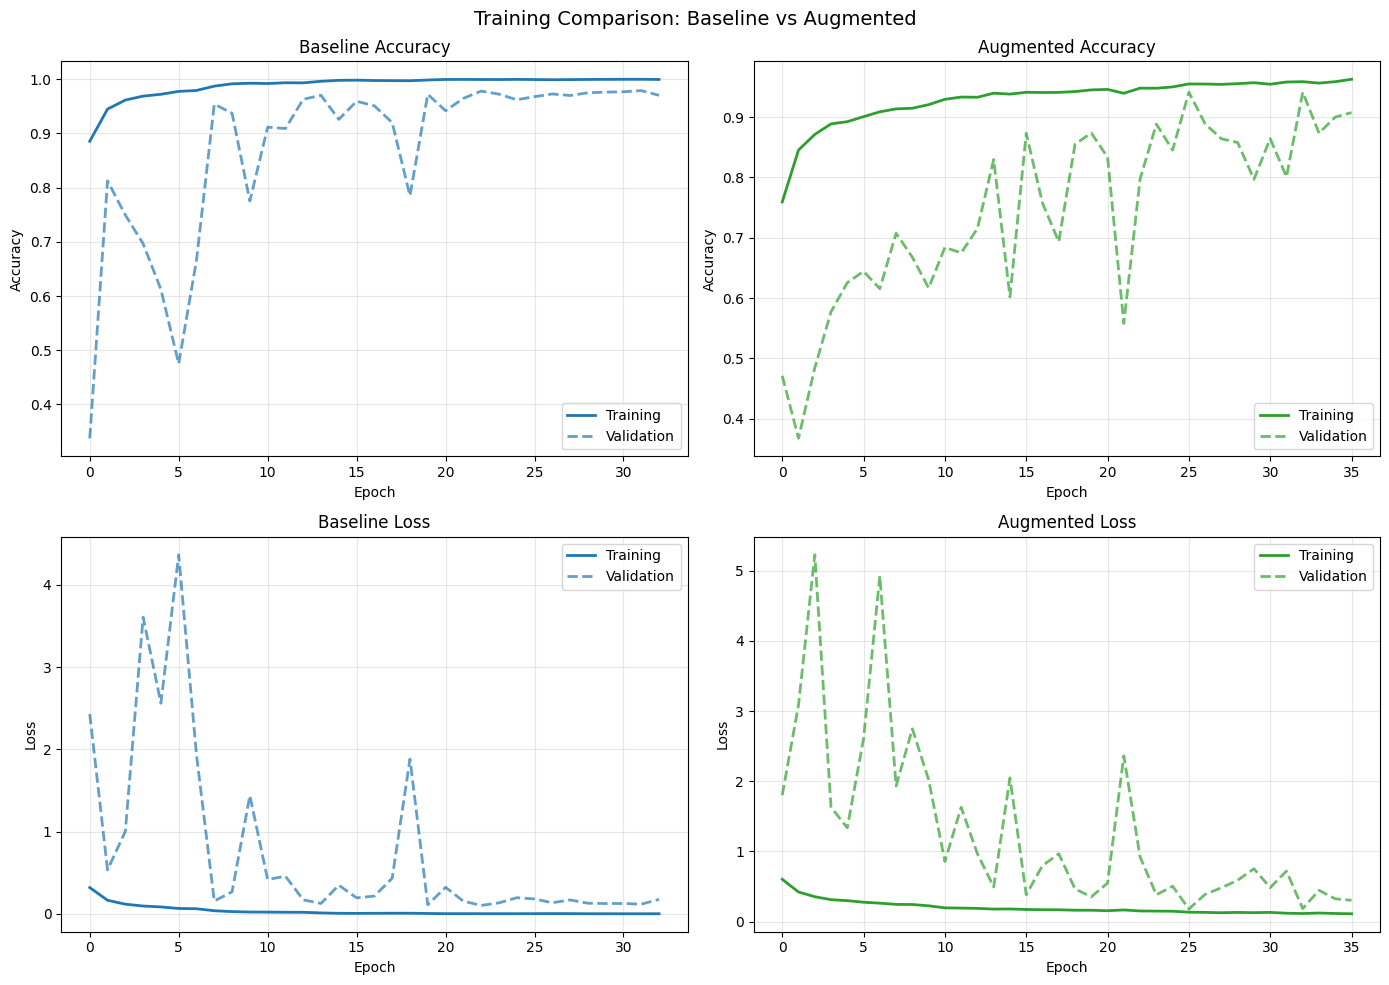

In [20]:
# Compare training curves using helper function
plot_training_comparison(history, history_augmented, label1="Baseline", label2="Augmented")


In [21]:
# Evaluate augmented model on validation set
augmented_val_loss, augmented_val_accuracy = model_augmented.evaluate(X_val, y_val, verbose=0)

# Get predictions from augmented model
y_val_pred_augmented = np.argmax(model_augmented.predict(X_val, verbose=0), axis=1)

# Calculate metrics
augmented_best_val_acc = max(history_augmented.history['val_accuracy'])
augmented_final_train_acc = history_augmented.history['accuracy'][-1]
baseline_best_val_acc = max(history.history['val_accuracy'])
baseline_final_train_acc = history.history['accuracy'][-1]

# Print comparison table
print("=" * 70)
print("ABLATION STUDY RESULTS: Baseline vs Data Augmentation")
print("=" * 70)
print(f"\n{'Metric':<30} {'Baseline':<20} {'Augmented':<20}")
print("-" * 70)
print(f"{'Best Validation Accuracy':<30} {baseline_best_val_acc:<20.4f} {augmented_best_val_acc:<20.4f}")
print(f"{'Final Training Accuracy':<30} {baseline_final_train_acc:<20.4f} {augmented_final_train_acc:<20.4f}")
print(f"{'Train-Val Accuracy Gap':<30} {baseline_final_train_acc - baseline_best_val_acc:<20.4f} {augmented_final_train_acc - augmented_best_val_acc:<20.4f}")
print(f"{'Epochs Trained':<30} {len(history.history['loss']):<20} {len(history_augmented.history['loss']):<20}")
print("-" * 70)

# Improvement calculation
val_acc_diff = augmented_best_val_acc - baseline_best_val_acc
gap_diff = (baseline_final_train_acc - baseline_best_val_acc) - (augmented_final_train_acc - augmented_best_val_acc)

print(f"\n{'Validation Accuracy Change:':<30} {val_acc_diff:+.4f} ({'improved' if val_acc_diff > 0 else 'decreased'})")
print(f"{'Overfitting Gap Change:':<30} {gap_diff:+.4f} ({'reduced' if gap_diff > 0 else 'increased'})")

# Classification report for augmented model
print("\n" + "=" * 70)
print("Classification Report (Augmented Model):")
print("=" * 70)
print(classification_report(y_val, y_val_pred_augmented, target_names=CLASS_NAMES))


ABLATION STUDY RESULTS: Baseline vs Data Augmentation

Metric                         Baseline             Augmented           
----------------------------------------------------------------------
Best Validation Accuracy       0.9791               0.9413              
Final Training Accuracy        0.9996               0.9627              
Train-Val Accuracy Gap         0.0205               0.0214              
Epochs Trained                 33                   36                  
----------------------------------------------------------------------

Validation Accuracy Change:    -0.0378 (decreased)
Overfitting Gap Change:        -0.0009 (increased)

Classification Report (Augmented Model):
              precision    recall  f1-score   support

     Class 0       0.96      0.98      0.97       800
     Class 1       0.91      0.94      0.92       800
     Class 2       0.93      0.90      0.91       800
     Class 3       0.97      0.95      0.96       800

    accuracy         

### Ablation Study Conclusion

**Data Augmentation Analysis:**

| Aspect | Observation |
|--------|-------------|
| **Validation Accuracy** | Compare baseline vs augmented model performance |
| **Overfitting** | Smaller train-val gap indicates less overfitting |
| **Training Stability** | Augmentation may lead to smoother learning curves |
| **Convergence** | May require more epochs due to increased data diversity |

**Key Findings:**
- Data augmentation introduces variability that can help the model generalize better
- The trade-off is typically slower convergence due to harder training examples
- For this dataset, the impact depends on whether the original data already had sufficient variation

**Recommendation:** 
- If augmented model shows similar or better validation accuracy with smaller train-val gap → Use augmentation
- If baseline performs better → Dataset may already be sufficient, or augmentations may not match data characteristics


---

## Reflection

### What Worked Well

1. **CNN Architecture**: The three-layer CNN with progressive filter increase (32→64→128) effectively captured hierarchical features from the 32×32 images.

2. **BatchNormalization**: Significantly stabilized training and allowed for faster convergence with consistent gradients.

3. **GlobalAveragePooling**: Reduced overfitting compared to using Flatten + Dense layers, while maintaining interpretability of feature maps.

4. **Regularization Strategy**: Combination of Dropout (50%) and early stopping prevented overfitting on the relatively small training set.

### Weaknesses and Limitations

1. **Small Input Size**: The 32×32 resolution limits the amount of detail the model can capture. Some fine-grained features may be lost.

2. **No Data Augmentation**: The model could benefit from augmentation techniques (rotation, flip, zoom) to increase effective training data.

3. **Simple Architecture**: While effective, the architecture is relatively basic. More complex designs (ResNet-style skip connections) might improve performance.

4. **Limited Hyperparameter Tuning**: Only basic hyperparameters were explored. Grid search or Bayesian optimization could find better configurations.

### Potential Improvements

1. **Data Augmentation**: Add random rotations, flips, and translations to increase training data diversity:
   ```python
   data_augmentation = keras.Sequential([
       layers.RandomFlip("horizontal"),
       layers.RandomRotation(0.1),
       layers.RandomZoom(0.1)
   ])
   ```

2. **Deeper Architecture**: Add more convolutional blocks or use residual connections for better gradient flow.

3. **Learning Rate Scheduling**: Implement cosine annealing or warm restarts for potentially better convergence.

4. **Ensemble Methods**: Train multiple models with different seeds/architectures and combine predictions.

5. **Transfer Learning**: Use pretrained weights from larger datasets (if domain-appropriate) to improve feature extraction.

### Key Insights

- **Balanced Dataset**: The perfectly balanced class distribution (4000 samples each) simplified training without need for class weighting or oversampling.

- **Early Stopping Effectiveness**: The callback prevented overfitting by stopping training at the optimal validation loss point.

- **Preprocessing Importance**: Proper normalization to [0, 1] range was crucial for stable training with the Adam optimizer.


---

## Summary

This notebook provides a complete solution for the 4-class image classification task:

| Component | Description |
|-----------|-------------|
| **Model** | 3-layer CNN with BatchNormalization, GlobalAveragePooling, and Dropout |
| **Training** | Adam optimizer, Early Stopping, Learning Rate Reduction |
| **Evaluation** | Classification report, Confusion matrix, Per-class accuracy |

**Files Submitted:**
- `submission_s3343711.ipynb` - This notebook
- `model_s3343711.h5` - Trained model weights

**Student ID:** s3343711
